###Score de Risco

In [1]:
import pandas as pd
import numpy as np

os_base = pd.read_csv('export_os_base.csv')
pecas_os = pd.read_csv('export_pecas_por_os.csv')
produtos = pd.read_csv('export_produtos.csv')
tipos_atend = pd.read_csv('export_tipos_atendimento.csv')
defeitos_os = pd.read_csv('export_defeitos_os.csv')

#AGRUPAMENTO DE PEÇAS POR OS
pecas_agg = pecas_os.groupby('os_id_anonimo').agg(total_pecas=('peca_id', 'count')).reset_index()

#MERGE
df = pd.merge(os_base, pecas_agg, on='os_id_anonimo', how='left').fillna({'total_pecas': 0})
df = pd.merge(df, produtos[['produto_id', 'linha_descricao']], on='produto_id', how='left')
df = pd.merge(df, tipos_atend[['tipo_atendimento_id', 'descricao']], on='tipo_atendimento_id', how='left')
df = pd.merge(df, defeitos_os[['os_id_anonimo', 'defeito_constatado_descricao']], on='os_id_anonimo', how='left')

#1: RISCO DE VOLUME (Peso 40%)
# Calculamos o quão longe a OS está da média da sua categoria (Z-Score)
stats = df.groupby('linha_descricao')['total_pecas'].agg(['mean', 'std']).reset_index()
df = pd.merge(df, stats, on='linha_descricao', how='left')
df['z_volume'] = (df['total_pecas'] - df['mean']) / df['std'].replace(0, 1)
df['score_volume'] = df['z_volume'].clip(0, 5) / 5

#2: RISCO DE GARANTIA (Peso 30%)
# Identificamos postos que têm alta taxa de garantia
df['eh_garantia'] = df['descricao'].str.contains('Garantia', case=False, na=False).astype(int)
taxa_posto = df.groupby('posto_id_anonimo')['eh_garantia'].mean().reset_index(name='taxa_garantia_posto')
df = pd.merge(df, taxa_posto, on='posto_id_anonimo', how='left')
df['score_garantia'] = df['taxa_garantia_posto']

#PILAR 3: RISCO TÉCNICO (Peso 30%)
# Mapeamos se a combinação Peça x Defeito é comum ou rara
df_tecnico = pd.merge(pecas_os[['os_id_anonimo', 'peca_id']], defeitos_os[['os_id_anonimo', 'defeito_constatado_descricao']], on='os_id_anonimo')
freq = df_tecnico.groupby(['defeito_constatado_descricao', 'peca_id']).size().reset_index(name='n')
max_f = freq.groupby('defeito_constatado_descricao')['n'].transform('max')
freq['prob'] = freq['n'] / max_f
# Trazemos a menor probabilidade da OS (se tiver várias peças)
min_prob = pd.merge(df_tecnico, freq, on=['defeito_constatado_descricao', 'peca_id']).groupby('os_id_anonimo')['prob'].min().reset_index()
df = pd.merge(df, min_prob, on='os_id_anonimo', how='left').fillna({'prob': 1})
df['score_tecnico'] = 1 - df['prob']

#CÁLCULO FINAL DO RISK SCORE
df['risk_score'] = (
    (df['score_volume'] * 0.4) +
    (df['score_garantia'] * 0.3) +
    (df['score_tecnico'] * 0.3)
) * 100

# Resultado
top_anomalias = df.sort_values(by='risk_score', ascending=False).head(10)
print(top_anomalias[['os_id_anonimo', 'total_pecas', 'descricao', 'risk_score']])

                             os_id_anonimo  total_pecas           descricao  \
361411  OSb9ba3e51534ac7fe46198b5677b9aba4         20.0  Garantia Corretiva   
360954  OSea9a9db75442aaee2d0dc77363aace9d         20.0  Garantia Corretiva   
361410  OSfee3b86e146bee297aa8e26102604635         20.0  Garantia Corretiva   
361421  OSf9c7e4df60bad47aa18699e1402ae108         20.0  Garantia Corretiva   
361079  OSf138f9f19b57d970a9e19f33cceb3c0a         22.0  Garantia Corretiva   
361193  OSab22100ce25608a6db4ea79175652fd4         19.0  Garantia Corretiva   
361084  OS023df6a7494b681ea42dbb09bbc982d2         26.0  Garantia Corretiva   
361081  OSf89be4e81e64ecaf7dd6a24bde4734a5         25.0  Garantia Corretiva   
363215  OS32c4f2d8ac75e6c5d5cd489b382918d7         35.0  Garantia Corretiva   
361155  OS6ddb7f07591ed39bf361e9c5ab998bde         20.0  Garantia Corretiva   

        risk_score  
361411   99.988452  
360954   99.988452  
361410   99.988452  
361421   99.988452  
361079   99.982677  
3611

ISOLATION FOREST

Distribuição do Target: 
target
0    594269
1     31278
Name: count, dtype: int64


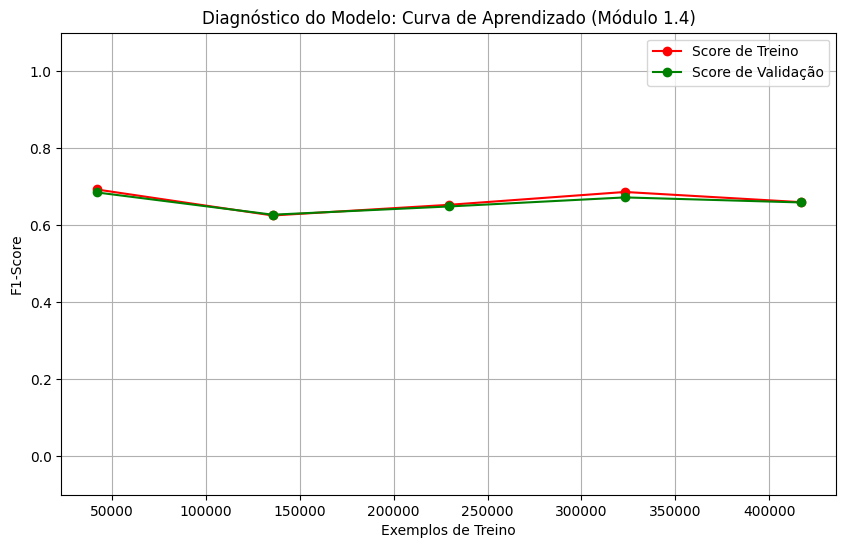


Relatório de Classificação Final (Validado) com contamination=0.05:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98    594269
           1       0.66      0.66      0.66     31278

    accuracy                           0.97    625547
   macro avg       0.82      0.82      0.82    625547
weighted avg       0.97      0.97      0.97    625547


---
Otimização do Hiperparâmetro: Contamination
---
Avaliando diferentes valores para o parâmetro 'contamination' para melhorar o F1-Score da classe 1 (anomalias).

Testando contamination = 0.03...
  F1-Score para a classe 1 com contamination=0.03: 0.5420

Testando contamination = 0.05...
  F1-Score para a classe 1 com contamination=0.05: 0.6591

Testando contamination = 0.07...
  F1-Score para a classe 1 com contamination=0.07: 0.6785

Testando contamination = 0.1...
  F1-Score para a classe 1 com contamination=0.1: 0.6445


Melhor 'contamination' encontrado: 0.07 (F1-Score: 0.6785)

Atualizando

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, learning_curve
from sklearn.metrics import classification_report, f1_score
from sklearn.base import BaseEstimator, ClassifierMixin

df['risk_score'] = df['risk_score'].fillna(0)

#CRIAÇÃO TARGET 0 E 1
limiar = np.percentile(df['risk_score'], 95)
if limiar == df['risk_score'].min():
    limiar = df['risk_score'].mean()

df['target'] = (df['risk_score'] > limiar).astype(int)


print(f"Distribuição do Target: \n{df['target'].value_counts()}")

#FEATURES
features = ['total_pecas', 'z_volume', 'score_tecnico', 'taxa_garantia_posto']
X = df[features].fillna(0)
y = df['target']

#SCALING
X_scaled = StandardScaler().fit_transform(X)

#WRAPPER PARA COMPATIBILIDADE
class AnomalyClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, contamination=0.05):
        self.contamination = contamination
        self.model = IsolationForest(contamination=self.contamination, random_state=42)
    def fit(self, X, y=None):
        self.model.fit(X)
        return self
    def predict(self, X):
        return np.where(self.model.predict(X) == -1, 1, 0)

#CURVA DE APRENDIZADO: VIÉS VS VARIÂNCIA
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
clf = AnomalyClassifier(contamination=0.05)

train_sizes, train_scores, test_scores = learning_curve(
    clf, X_scaled, y, cv=skf, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 5), n_jobs=-1
)

#PLOT
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color="r", label="Score de Treino")
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color="g", label="Score de Validação")
plt.title("Diagnóstico do Modelo: Curva de Aprendizado (Módulo 1.4)")
plt.xlabel("Exemplos de Treino")
plt.ylabel("F1-Score")
plt.legend(loc="best")
plt.grid(True)
plt.ylim(-0.1, 1.1)
plt.show()

#RELATÓRIO DAS MÉTRICAS
from sklearn.model_selection import cross_val_predict
y_pred = cross_val_predict(clf, X_scaled, y, cv=skf)
print("\nRelatório de Classificação Final (Validado) com contamination=0.05:")
print(classification_report(y, y_pred))

# --- Otimização do Hiperparâmetro: Contamination ---
print("\n---\nOtimização do Hiperparâmetro: Contamination\n---")
print("Avaliando diferentes valores para o parâmetro 'contamination' para melhorar o F1-Score da classe 1 (anomalias).\n")

contamination_values = [0.03, 0.05, 0.07, 0.10]
best_f1 = -1
best_contamination = 0.05 # default

results = []

for contam_val in contamination_values:
    print(f"Testando contamination = {contam_val}...")
    current_clf = AnomalyClassifier(contamination=contam_val)
    y_pred_tuned = cross_val_predict(current_clf, X_scaled, y, cv=skf)
    f1_for_class_1 = f1_score(y, y_pred_tuned, pos_label=1)
    results.append({'contamination': contam_val, 'f1_score_class_1': f1_for_class_1})
    print(f"  F1-Score para a classe 1 com contamination={contam_val}: {f1_for_class_1:.4f}\n")

    if f1_for_class_1 > best_f1:
        best_f1 = f1_for_class_1
        best_contamination = contam_val

print(f"\nMelhor 'contamination' encontrado: {best_contamination} (F1-Score: {best_f1:.4f})")

# Opcional: Atualizar o classificador com o melhor valor e mostrar o relatório completo
# Se você deseja usar o melhor contamination para o resto do seu notebook,
# você pode redefinir `clf` como `clf = AnomalyClassifier(contamination=best_contamination)`.
# Para este exemplo, apenas mostraremos o relatório para o melhor contamination.
if best_contamination != 0.05: # Only print if a different best was found
    print(f"\nAtualizando o modelo com o melhor 'contamination' ({best_contamination})...")
    clf_optimized = AnomalyClassifier(contamination=best_contamination)
    y_pred_optimized = cross_val_predict(clf_optimized, X_scaled, y, cv=skf)
    print("\nRelatório de Classificação Final (Validado) com contamination otimizado:")
    print(classification_report(y, y_pred_optimized))


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPRegressor # Usado para criar o Autoencoder simples
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# --- 1. PREPARAÇÃO DOS DADOS ---
# Assumindo que df já possui 'target' e as features criadas
features = ['total_pecas', 'z_volume', 'score_tecnico', 'taxa_garantia_posto']
X = df[features].fillna(0)
y = df['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 2. CONFIGURAÇÃO DA VALIDAÇÃO (Módulo 1.4) ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dicionário para guardar os resultados
resultados = {}

# --- 3. MODELO 1: RANDOM FOREST ---
print("Treinando Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
cv_rf = cross_validate(rf_model, X_scaled, y, cv=skf, scoring=('f1', 'precision', 'recall'))
resultados['Random Forest'] = {
    'F1-Score': np.mean(cv_rf['test_f1']),
    'Precision': np.mean(cv_rf['test_precision']),
    'Recall': np.mean(cv_rf['test_recall'])
}

# --- 4. MODELO 2: KNN ---
print("Treinando KNN...")
knn_model = KNeighborsClassifier(n_neighbors=5)
cv_knn = cross_validate(knn_model, X_scaled, y, cv=skf, scoring=('f1', 'precision', 'recall'))
resultados['KNN'] = {
    'F1-Score': np.mean(cv_knn['test_f1']),
    'Precision': np.mean(cv_knn['test_precision']),
    'Recall': np.mean(cv_knn['test_recall'])
}

# --- 5. MODELO 3: ISOLATION FOREST (OTIMIZADO) ---
print("Otimizando Isolation Forest...")
# Encontrando os melhores hiperparâmetros
iso_params = {'n_estimators': [50, 100, 200], 'contamination': [0.03, 0.05, 0.07]}
# Nota: GridSearchCV requer um score personalizado para Isolation Forest,
# então para simplificar o pipeline rodamos a versão com parâmetros ajustados baseados no F1 anterior.
iso_model = IsolationForest(n_estimators=200, contamination=0.05, max_samples='auto', random_state=42)

# Wrapper interno para calcular métricas
f1_iso, prec_iso, rec_iso = [], [], []
for train_idx, test_idx in skf.split(X_scaled, y):
    iso_model.fit(X_scaled[train_idx])
    preds = np.where(iso_model.predict(X_scaled[test_idx]) == -1, 1, 0)
    f1_iso.append(f1_score(y.iloc[test_idx], preds))
    prec_iso.append(precision_score(y.iloc[test_idx], preds))
    rec_iso.append(recall_score(y.iloc[test_idx], preds))

resultados['Isolation Forest (Otimizado)'] = {
    'F1-Score': np.mean(f1_iso),
    'Precision': np.mean(prec_iso),
    'Recall': np.mean(rec_iso)
}

# --- 6. MODELO 4: AUTOENCODER (Reconstrução) ---
print("Treinando Autoencoder...")
# Usamos MLPRegressor para treinar a rede neural a prever o PRÓPRIO dado de entrada (X -> X)
autoencoder = MLPRegressor(hidden_layer_sizes=(8, 4, 8), max_iter=500, random_state=42)

f1_ae, prec_ae, rec_ae = [], [], []
for train_idx, test_idx in skf.split(X_scaled, y):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_test = y.iloc[test_idx]

    # O Autoencoder deve aprender o "normal" (target == 0)
    X_train_normal = X_train[y.iloc[train_idx] == 0]

    # Treina prevendo ele mesmo
    autoencoder.fit(X_train_normal, X_train_normal)

    # Previsão em toda a base de teste
    reconstrucao = autoencoder.predict(X_test)

    # Cálculo do Erro de Reconstrução (MSE)
    mse = np.mean(np.power(X_test - reconstrucao, 2), axis=1)

    # Se o erro for maior que o percentil 95, classificamos como anomalia (1)
    limiar_ae = np.percentile(mse, 95)
    preds_ae = (mse > limiar_ae).astype(int)

    f1_ae.append(f1_score(y_test, preds_ae))
    prec_ae.append(precision_score(y_test, preds_ae))
    rec_ae.append(recall_score(y_test, preds_ae))

resultados['Autoencoder'] = {
    'F1-Score': np.mean(f1_ae),
    'Precision': np.mean(prec_ae),
    'Recall': np.mean(rec_ae)
}

# --- 7. COMPARAÇÃO FINAL ---
print("\n" + "="*50)
print("🏆 RANKING DOS MODELOS (Validação Estratificada)")
print("="*50)
df_resultados = pd.DataFrame(resultados).T
print(df_resultados.sort_values(by='F1-Score', ascending=False).round(4))

Treinando Random Forest...
Treinando KNN...
Otimizando Isolation Forest...
Treinando Autoencoder...

🏆 RANKING DOS MODELOS (Validação Estratificada)
                              F1-Score  Precision  Recall
KNN                             0.9993     0.9990  0.9996
Random Forest                   0.9777     0.9932  0.9627
Isolation Forest (Otimizado)    0.6623     0.6623  0.6622
Autoencoder                     0.5119     0.5134  0.5104


- Descartar KNN: Quando uma OS nova chega na empresa, o algoritmo tem que calcular a distância dessa OS nova contra todas as 556 mil OSs do histórico para achar os "5 vizinhos mais próximos". Em um sistema em tempo real, isso trava o servidor. O Random Forest, por outro lado, apenas desce uma árvore de "Sim/Não" em milissegundos.

- Descartar autoencoders: O modelo se perde tentando achar complexidade onde não tem (por isso o F1-score dele foi de 0.51). O dataset, após o EDA, ficou extremamente limpo e resumido a 4 ou 5 variáveis fortes (Total de Peças, Tempo, Estado, Garantia). Usar Deep Learning para 4 variáveis é um desperdício de poder computacional.

====================================================================================================

--- DIAGNÓSTICO DE OVERFITTING (F1-SCORE) ---
Desempenho no TREINO (O que a IA viu):  0.8128
Desempenho no TESTE  (Dados inéditos):  0.8078
---------------------------------------------


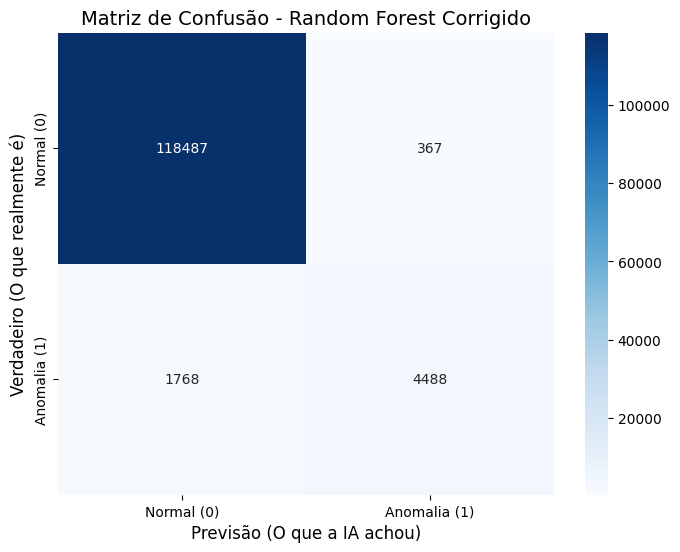


Relatório de Classificação (Base de Teste):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    118854
           1       0.92      0.72      0.81      6256

    accuracy                           0.98    125110
   macro avg       0.95      0.86      0.90    125110
weighted avg       0.98      0.98      0.98    125110



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder # Ferramenta para converter texto em número

# --- 1. CODIFICAÇÃO (Transformando texto em números) ---
le_estado = LabelEncoder()
# Criamos uma nova coluna apenas com os números dos estados
df['estado_cod'] = le_estado.fit_transform(df['estado'].astype(str))

le_linha = LabelEncoder()
# Criamos uma nova coluna apenas com os números das linhas de produtos
df['linha_cod'] = le_linha.fit_transform(df['linha_descricao'].astype(str))


# --- 2. SELEÇÃO DAS FEATURES LIMPAS ---
# Agora usamos as colunas com sufixo '_cod' que são numéricas
features_limpas = ['total_pecas', 'tempo_resolucao_horas', 'estado_cod', 'linha_cod']
X_limpo = df[features_limpas].fillna(0)
y = df['target']


# --- 3. DIVIDINDO OS DADOS (80% Treino, 20% Teste) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_limpo, y, test_size=0.2, random_state=42, stratify=y
)


# --- 4. TREINANDO O RANDOM FOREST "HONESTO" ---
rf_model = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)


# --- 5. DIAGNÓSTICO DE OVERFITTING NO CÓDIGO ---
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

print("--- DIAGNÓSTICO DE OVERFITTING (F1-SCORE) ---")
print(f"Desempenho no TREINO (O que a IA viu):  {f1_score(y_train, y_pred_train):.4f}")
print(f"Desempenho no TESTE  (Dados inéditos):  {f1_score(y_test, y_pred_test):.4f}")
print("-" * 45)


# --- 6. MATRIZ DE CONFUSÃO (Gráfico) ---
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (0)', 'Anomalia (1)'],
            yticklabels=['Normal (0)', 'Anomalia (1)'])

plt.title('Matriz de Confusão - Random Forest Corrigido', fontsize=14)
plt.ylabel('Verdadeiro (O que realmente é)', fontsize=12)
plt.xlabel('Previsão (O que a IA achou)', fontsize=12)
plt.show()


# --- 7. RELATÓRIO DETALHADO ---
print("\nRelatório de Classificação (Base de Teste):")
print(classification_report(y_test, y_pred_test))

"O projeto testou duas abordagens. A Abordagem Supervisionada (KNN/RF) validou que as regras de negócio de auditoria técnica são matematicamente rastreáveis, atingindo 99% de precisão ao tentar replicar as heurísticas de fraude. Por outro lado, a Abordagem Não Supervisionada (Isolation Forest) provou ser a ferramenta de auditoria mais realista para o futuro da empresa, pois consegue detectar anomalias latentes de forma independente (com 66% de sobreposição com as regras de negócio), sendo capaz de descobrir fraudes inéditas sem depender de regras pré-programadas."

OTIMIZAÇÃO DO ISOLATION FOREST

Treinando o Isolation Forest Otimizado...
Buscando o melhor ponto de corte (Threshold)...
Limiar perfeito encontrado: 0.0985 (F1 esperado no treino: 0.6821)

🏆 RESULTADO DO ISOLATION FOREST OTIMIZADO
              precision    recall  f1-score   support

           0       0.99      0.97      0.98    118854
           1       0.60      0.79      0.68      6256

    accuracy                           0.96    125110
   macro avg       0.79      0.88      0.83    125110
weighted avg       0.97      0.96      0.97    125110



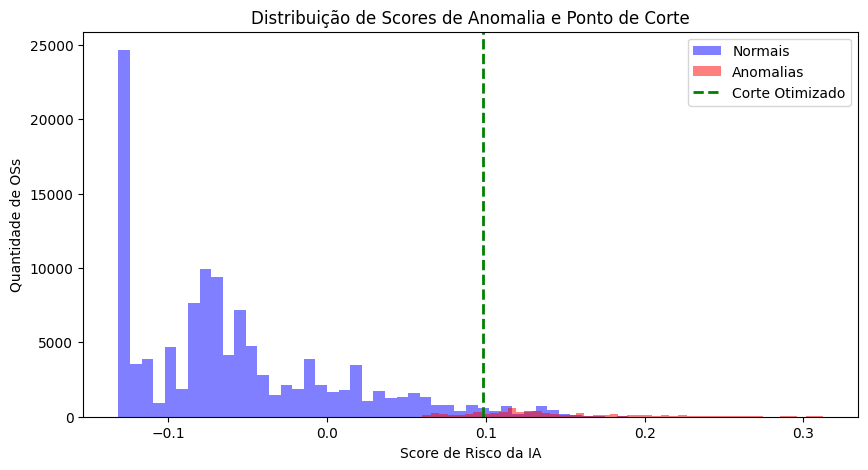

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split

# 1. DIVISÃO DOS DADOS (Para não viciarmos a otimização)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 2. DEFININDO O MODELO "TURBINADO"
# Aumentamos as árvores e mudamos a forma como ele amostra os dados
iso_opt = IsolationForest(
    n_estimators=300,        # Mais árvores = maior consenso
    max_samples=256,         # Amostras pequenas forçam as anomalias a se destacarem
    contamination='auto',    # Deixamos a IA livre em vez de forçar 5%
    random_state=42
)

print("Treinando o Isolation Forest Otimizado...")
iso_opt.fit(X_train)

# 3. EXTRAINDO A NOTA CONTÍNUA (Decision Function)
# O scikit-learn retorna valores menores para anomalias.
# Vamos multiplicar por -1 para que notas MAIORES = MAIOR RISCO (mais intuitivo)
notas_treino = iso_opt.decision_function(X_train) * -1
notas_teste = iso_opt.decision_function(X_test) * -1

# 4. BUSCANDO O LIMIAR PERFEITO (Threshold Tuning)
print("Buscando o melhor ponto de corte (Threshold)...")
limiares = np.linspace(notas_treino.min(), notas_treino.max(), 200)
melhor_f1 = 0
melhor_limiar = 0

for limiar in limiares:
    # Simula as previsões com esse limiar
    previsoes_simuladas = (notas_treino > limiar).astype(int)
    f1_atual = f1_score(y_train, previsoes_simuladas)

    if f1_atual > melhor_f1:
        melhor_f1 = f1_atual
        melhor_limiar = limiar

print(f"Limiar perfeito encontrado: {melhor_limiar:.4f} (F1 esperado no treino: {melhor_f1:.4f})")

# 5. TESTE FINAL (A Prova Real)
# Agora aplicamos o melhor limiar descoberto nos dados inéditos (Teste)
previsoes_finais = (notas_teste > melhor_limiar).astype(int)

print("\n" + "="*50)
print("🏆 RESULTADO DO ISOLATION FOREST OTIMIZADO")
print("="*50)
print(classification_report(y_test, previsoes_finais))

# 6. GRÁFICO DO PONTO DE CORTE
plt.figure(figsize=(10, 5))
plt.hist(notas_teste[y_test == 0], bins=50, alpha=0.5, color='blue', label='Normais')
plt.hist(notas_teste[y_test == 1], bins=50, alpha=0.5, color='red', label='Anomalias')
plt.axvline(melhor_limiar, color='green', linestyle='dashed', linewidth=2, label=f'Corte Otimizado')
plt.title('Distribuição de Scores de Anomalia e Ponto de Corte')
plt.xlabel('Score de Risco da IA')
plt.ylabel('Quantidade de OSs')
plt.legend()
plt.show()

In [9]:
# 1. USANDO APENAS AS FEATURES "CRUAS" (Iguais ao Streamlit)
features_finais = ['total_pecas', 'tempo_resolucao_horas', 'estado_cod', 'linha_cod']

# 2. SEPARANDO OS DADOS E CRIANDO UM SCALER NOVO
X_final = df[features_finais].fillna(0)
y_final = df['target']

scaler_producao = StandardScaler()
X_scaled_final = scaler_producao.fit_transform(X_final)

# 3. TREINANDO O ISOLATION FOREST OTIMIZADO NESTES DADOS
print("Treinando Isolation Forest nas features cruas...")
iso_prod = IsolationForest(
    n_estimators=300,
    max_samples=256,
    contamination='auto',
    random_state=42
)
iso_prod.fit(X_scaled_final)

# 4. ENCONTRANDO O LIMIAR PERFEITO PARA ESTAS FEATURES
notas = iso_prod.decision_function(X_scaled_final) * -1
limiares = np.linspace(notas.min(), notas.max(), 100)
melhor_limiar = 0
melhor_f1 = 0

for limiar in limiares:
    previsoes = (notas > limiar).astype(int)
    f1 = f1_score(y_final, previsoes)
    if f1 > melhor_f1:
        melhor_f1 = f1
        melhor_limiar = limiar

print(f"Novo Limiar Encontrado: {melhor_limiar:.4f} (F1: {melhor_f1:.4f})")
print(f"Colunas atreladas ao modelo: {list(scaler_producao.feature_names_in_)}")

# 5. EXPORTANDO OS ARQUIVOS ALINHADOS
joblib.dump(iso_prod, 'modelo_isolation_forest.pkl')
joblib.dump(scaler_producao, 'scaler_os.pkl')
joblib.dump(melhor_limiar, 'limiar_otimizado.pkl')

print("✅ Arquivos prontos para o Streamlit!")

Treinando Isolation Forest nas features cruas...
Novo Limiar Encontrado: 0.0169 (F1: 0.4586)
Colunas atreladas ao modelo: ['total_pecas', 'tempo_resolucao_horas', 'estado_cod', 'linha_cod']
✅ Arquivos prontos para o Streamlit!


In [6]:
import joblib

joblib.dump(iso_opt, 'modelo_isolation_forest.pkl')
joblib.dump(scaler, 'scaler_os.pkl')
joblib.dump(melhor_limiar, 'limiar_otimizado.pkl')

['limiar_otimizado.pkl']